# Assignment 3: Linear Models

Timothy Lee (ghk5cv)

**Q1.** Please answer the following questions in your own words.

1. What makes a model "linear"? "Linear" in what?

A model is called "linear" when its coefficients are added together in a simple, straightforward way. The variables themselves can be squared or logged, but the weights are never multiplied together or raised to any power.

2. How do you interpret the coefficient for a dummy/one-hot-encoded variable? (Hint: how do you handle the intercept of the model?)

When one category is dropped as the reference group, the intercept captures the baseline outcome for that omitted group. Each dummy coefficient then tells you how much the outcome changes for that group compared to the baseline.

3. Can linear regression be used for classification? Explain why, or why not.

Not really. Linear regression can output values below 0 or above 1, which makes no sense for a binary outcome. Logistic regression is the better tool because it keeps all predictions between 0 and 1.

4. What are signs that your linear model is over-fitting?

The biggest sign is when your model does really well on training data but falls apart on new data. You might also notice coefficients shifting a lot with small changes in the dataset, or residual plots that look like the model is picking up on random noise rather than any real pattern.

5. Clearly explain multi-colinearity using the two-stage least squares technique.

Multicollinearity happens when one predictor can mostly be explained by the others, leaving very little unique information for OLS to use. If you regress the suspect variable on all other regressors first, only the leftover residual carries unique information. When that residual is tiny, the coefficient becomes unstable and the standard error gets very large.

6. How can you incorporate nonlinear relationships between your target/response/dependent/outcome variable $y$ and your features/control/response/independent variables $x$ into your analysis?

You can transform the features themselves since linearity only requires the coefficients to be linear. Adding squared terms, logs, interaction terms, or splines all work well. Including both x and x squared, for example, lets the model capture a curved relationship while still being a standard linear regression.

7. What is the interpretation of the slope coefficient in a linear regression?

The slope coefficient tells you how much the outcome changes when one variable goes up by one unit, while everything else stays fixed. That last part matters a lot because it isolates each feature's individual effect from all the others in the model.
8. Compare the train/test split and $k$-fold cross validation.

A train/test split is simple and fast, but your result depends a lot on how that one split happened to go. K-fold cross validation rotates every observation through the test set across k rounds and averages the results, so no single split can throw off your evaluation. It takes more computation, but gives you a much more reliable sense of how your model actually generalizes.

9. How is the $k$ in $k$-fold cross validation typically selected?

It really comes down to dataset size and how much computation you can afford. For larger datasets, k=5 is usually good enough. For smaller ones, k=10 works better since you want as much training data as possible in each fold. In practice, 5 and 10 are the go-to defaults for most situations.

**Q2.** Load `./data/Q1_clean.csv`. The data include

- `Price` per night
- `Review Scores Rating`: The average rating for the property
- `Neighbourhood`: The bourough of NYC. Note the space, or rename the variable.

1. Compute the average prices and scores by `Neighbourhood`; which bourough is the most expensive on average? Create a kernel density plot of price and log price, grouping by `Neighbourhood`.
2. Regress price on `Neighbourhood` by creating the appropriate dummy/one-hot-encoded variables (Are you dropping the first category, or the intercept of the regresssion?). Compare the coefficients in the regression to the table from part 1 (the answer depends on how you handled the dummy variable trap). How are the conditional group means and the estimated coefficients related?
3. Regress price on `Review Scores Rating` and a constant/intercept. Interpret the slope coefficient clearly in words.
4. Regress price on both `Neighbourhood` and `Review Scores Rating`. How does the slope coefficient on `Review Scores Rating` change? How do the neighborhood averages change?
5. Here is a puzzle: Regress price on a constant, and a separate slope coefficient for each neighborhood for `Review Scores Rating`. Are the slopes similar across neighborhoods, or not?
6. Use cross validation to evaluate the models from parts 4, 5, and 6.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.formula.api as smf

df = pd.read_csv("./data/Q1_clean.csv")

#cleaning col names
df.columns = [c.strip().lower().replace(" ", "_") for c in df.columns]
df = df.rename(columns={
    "review_scores_rating": "review_score",
    "neighbourhood": "neighborhood"
})

df = df[["price", "review_score", "neighborhood"]].dropna()
df["price"] = pd.to_numeric(df["price"], errors="coerce")
df["review_score"] = pd.to_numeric(df["review_score"], errors="coerce")
df = df.dropna()
df["log_price"] = np.log(df["price"])

df.head()

,price,review_score,neighborhood,log_price
0,549,96.0,Manhattan,6.308098
1,149,100.0,Brooklyn,5.003946
2,250,100.0,Manhattan,5.521461
3,90,94.0,Brooklyn,4.499810
4,270,90.0,Manhattan,5.598422


# 2.1

In [4]:
summary = (
    df.groupby("neighborhood")
    .agg(
        mean_price=("price", "mean"),
        median_price=("price", "median"),
        mean_review=("review_score", "mean"),
        count=("price", "size")
    )
    .sort_values("mean_price", ascending=False)
)

print(summary)
print(f"\nMost expensive borough: {summary.index[0]} at ${summary['mean_price'].iloc[0]:.2f} avg/night")

               mean_price  median_price  mean_review  count
neighborhood                                               
Manhattan      183.664286         150.0    91.801496  11763
Staten Island  146.166667          71.0    90.843750     96
Brooklyn       127.747378         100.0    92.363497   8487
Queens          96.857233          80.0    91.549057   1590
Bronx           75.276498          60.0    91.654378    217

Most expensive borough: Manhattan at $183.66 avg/night


# 2.2

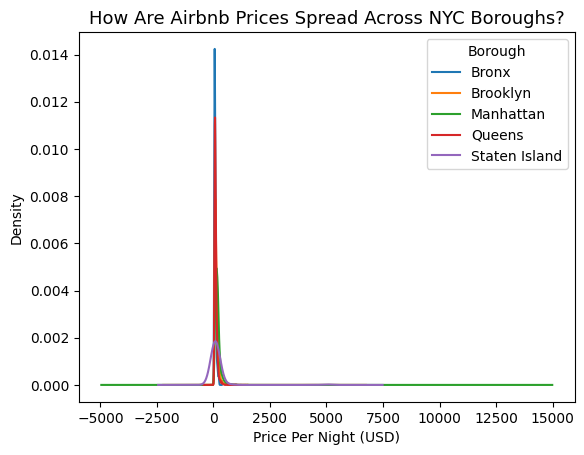

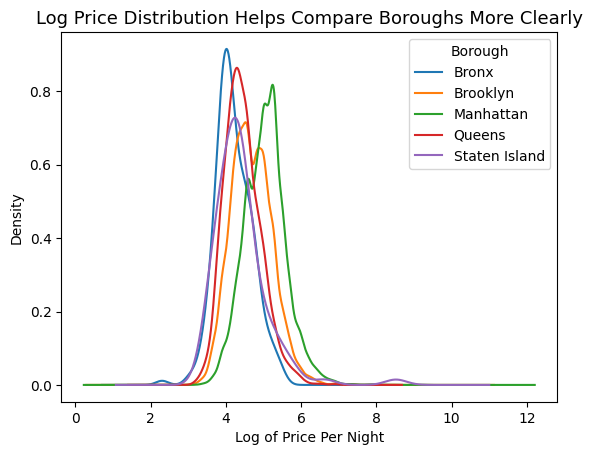

In [46]:
#gives us a KDE plot of raw price
fig, ax = plt.subplots()
for name, grp in df.groupby("neighborhood"):
    grp["price"].plot(kind="kde", ax=ax, label=name)
ax.set_title("How Are Airbnb Prices Spread Across NYC Boroughs?", fontsize=13)
ax.set_xlabel("Price Per Night (USD)")
ax.legend(title="Borough")
plt.show()

#gives us a KDE plot of log price
fig, ax = plt.subplots()
for name, grp in df.groupby("neighborhood"):
    grp["log_price"].plot(kind="kde", ax=ax, label=name)
ax.set_title("Log Price Distribution Helps Compare Boroughs More Clearly", fontsize=13)
ax.set_xlabel("Log of Price Per Night")
ax.legend(title="Borough")
plt.show()

In [8]:

mod_neighborhood = smf.ols("price ~ C(neighborhood)", data=df).fit()
print(mod_neighborhood.summary())

baseline = df["neighborhood"].astype("category").cat.categories[0]
baseline_mean = df.loc[df["neighborhood"] == baseline, "price"].mean()

print(f"\nBaseline (omitted): {baseline}, mean price: {baseline_mean:.2f}")
print("\nCoefficients:")
print(mod_neighborhood.params)

                            OLS Regression Results                            
Dep. Variable:                  price   R-squared:                       0.046
Model:                            OLS   Adj. R-squared:                  0.046
Method:                 Least Squares   F-statistic:                     268.9
Date:                Tue, 24 Mar 2026   Prob (F-statistic):          4.43e-226
Time:                        21:09:12   Log-Likelihood:            -1.4174e+05
No. Observations:               22153   AIC:                         2.835e+05
Df Residuals:                   22148   BIC:                         2.835e+05
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                                       coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------------------
Intercep

# 2.3

In [ ]:
mod_review = smf.ols("price ~ review_score", data=df).fit()
print(mod_review.summary())

b0 = mod_review.params["Intercept"]
b1 = mod_review.params["review_score"]

print(f"\nIntercept: {b0:.4f}")
print(f"Slope on review_score: {b1:.4f}")
print(f"\nInterpretation: A 1-point increase in review score is associated with")
print(f"an average change of ${b1:.2f} in price per night, holding nothing else fixed")

                            OLS Regression Results                            
Dep. Variable:                  price   R-squared:                       0.004
Model:                            OLS   Adj. R-squared:                  0.004
Method:                 Least Squares   F-statistic:                     81.92
Date:                Tue, 24 Mar 2026   Prob (F-statistic):           1.53e-19
Time:                        21:11:24   Log-Likelihood:            -1.4222e+05
No. Observations:               22153   AIC:                         2.844e+05
Df Residuals:                   22151   BIC:                         2.845e+05
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                   coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------
Intercept       60.8784     10.423      5.841   

# 2.4

In [11]:
mod_both = smf.ols("price ~ C(neighborhood) + review_score", data=df).fit()
print(mod_both.summary())

#compares review_score slope before and after adding neighborhood
comparison = pd.DataFrame({
    "review_only": mod_review.params.reindex(mod_both.params.index),
    "neighborhood_plus_review": mod_both.params
})
print("\nSlope comparison:")
print(comparison)

print("\nThe review_score slope changes after adding neighborhood controls,")
print("meaning part of the raw relationship was driven by neighborhood differences.")

                            OLS Regression Results                            
Dep. Variable:                  price   R-squared:                       0.050
Model:                            OLS   Adj. R-squared:                  0.050
Method:                 Least Squares   F-statistic:                     235.3
Date:                Tue, 24 Mar 2026   Prob (F-statistic):          1.21e-245
Time:                        21:11:54   Log-Likelihood:            -1.4169e+05
No. Observations:               22153   AIC:                         2.834e+05
Df Residuals:                   22147   BIC:                         2.834e+05
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
                                       coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------------------
Intercep

# 2.5

In [13]:
mod_interact = smf.ols("price ~ C(neighborhood) * review_score", data=df).fit()
print(mod_interact.summary())

#cmmputes implied slope per neighborhood
cats = df["neighborhood"].astype("category").cat.categories.tolist()
base_slope = mod_interact.params["review_score"]
slopes = {cats[0]: base_slope}

for c in cats[1:]:
    term = f"C(neighborhood)[T.{c}]:review_score"
    slopes[c] = base_slope + mod_interact.params.get(term, 0)

slope_series = pd.Series(slopes, name="review_score_slope").sort_values()
print("\nReview score slope by neighborhood:")
print(slope_series)
print("\nSlopes vary across neighborhoods, suggesting the effect of ratings on price differs by borough")

                            OLS Regression Results                            
Dep. Variable:                  price   R-squared:                       0.068
Model:                            OLS   Adj. R-squared:                  0.067
Method:                 Least Squares   F-statistic:                     178.4
Date:                Tue, 24 Mar 2026   Prob (F-statistic):               0.00
Time:                        21:13:02   Log-Likelihood:            -1.4149e+05
No. Observations:               22153   AIC:                         2.830e+05
Df Residuals:                   22143   BIC:                         2.831e+05
Df Model:                           9                                         
Covariance Type:            nonrobust                                         
                                                    coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------------------

# 2.6

In [14]:
from sklearn.model_selection import KFold

def cv_rmse(formula, data, k=10):
    y = data["price"].values
    kf = KFold(n_splits=k, shuffle=True, random_state=42)
    rmses = []
    for train_idx, test_idx in kf.split(data):
        train = data.iloc[train_idx]
        test = data.iloc[test_idx]
        fit = smf.ols(formula, data=train).fit()
        preds = fit.predict(test)
        rmse = np.sqrt(np.mean((test["price"].values - preds) ** 2))
        rmses.append(rmse)
    return np.mean(rmses), np.std(rmses)

formulas = {
    "review only":              "price ~ review_score",
    "neighborhood + review":    "price ~ C(neighborhood) + review_score",
    "neighborhood * review":    "price ~ C(neighborhood) * review_score"
}

results = []
for name, formula in formulas.items():
    mean_rmse, sd_rmse = cv_rmse(formula, df)
    results.append({"model": name, "mean_rmse": mean_rmse, "sd_rmse": sd_rmse})

cv_results = pd.DataFrame(results).sort_values("mean_rmse")
print(cv_results)

best = cv_results.iloc[0]["model"]
print(f"\nBest model by CV RMSE: {best}")

                   model   mean_rmse    sd_rmse
1  neighborhood + review  139.010186  41.796868
2  neighborhood * review  139.999082  41.514037
0            review only  142.759439  41.242175

Best model by CV RMSE: neighborhood + review


**Q3.** This question is a case study for linear models. The data are about car prices. In particular, they include:

  - `Price`: In Indian rupees
  - `Seating_Capacity`: Number of seats
  - `Body_Type`: crossover, hatchback, muv, sedan, suv
  - `Make_Year`: The year the car was made

  1. Load `cars_hw.csv`. Summarize the `Price` variable and create a kernel density plot. Use `.groupby()` and `.describe()` to summarize prices by `Body_Type`. Make a grouped kernel density plot by `Body_Type`. Which car types are the most expensive? Which have the most variance?
  2. Regress `Price` on `Seating_Capacity`. What's the slope coefficient? Interpret it. Now treat `Seating_Capacity` as a one hot encoded variable, and regress price on it as if it is categorical. Are the differences in price roughly linear in the number of seats?
  3. Use `Make_Year` to create a new variable that corresponds to the age of the vehicle. Use 10-fold cross validation to determine the optimal number of powers of `Age` to include in a regression of `Price` on `Age`. 
  4. Plot `Price` against `Age`, and then model-predicted price against `Age`. Does the model accurately fit the patterns in the data?


In [15]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import KFold, cross_val_score

cars = pd.read_csv("./data/cars_hw.csv")

#cleaning column names
cars.columns = [c.strip().replace(" ", "_") for c in cars.columns]
rename_map = {}
for c in cars.columns:
    lc = c.lower()
    if "price" in lc:
        rename_map[c] = "Price"
    elif "seating" in lc and "capacity" in lc:
        rename_map[c] = "Seating_Capacity"
    elif "body" in lc and "type" in lc:
        rename_map[c] = "Body_Type"
    elif "make" in lc and "year" in lc:
        rename_map[c] = "Make_Year"
cars = cars.rename(columns=rename_map)

required = ["Price", "Seating_Capacity", "Body_Type", "Make_Year"]
cars = cars[required].dropna().copy()
cars["Price"] = pd.to_numeric(cars["Price"], errors="coerce")
cars["Seating_Capacity"] = pd.to_numeric(cars["Seating_Capacity"], errors="coerce")
cars["Make_Year"] = pd.to_numeric(cars["Make_Year"], errors="coerce")
cars = cars.dropna()

cars.head()

,Price,Seating_Capacity,Body_Type,Make_Year
0,657000,5,sedan,2017
1,682000,5,crossover,2016
2,793000,5,suv,2019
3,414000,5,hatchback,2017
4,515000,5,hatchback,2017


# 3.1

In [16]:
#overall price summary
print(cars["Price"].describe())

count    9.760000e+02
mean     7.410195e+05
std      3.673234e+05
min      1.880000e+05
25%      4.757500e+05
50%      6.665000e+05
75%      8.830000e+05
max      2.941000e+06
Name: Price, dtype: float64


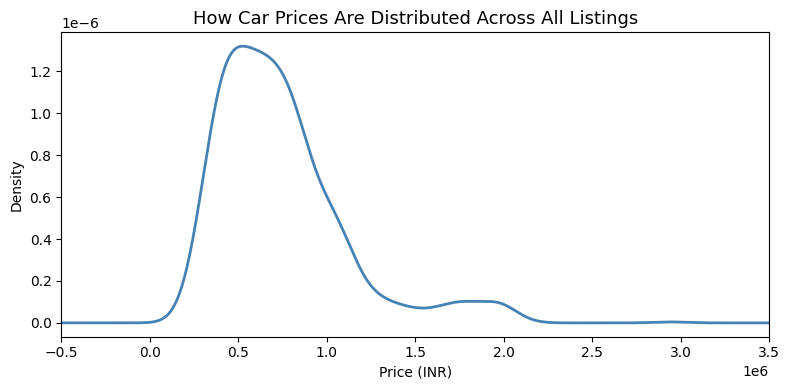

In [41]:
fig, ax = plt.subplots(figsize=(8, 4))
cars["Price"].plot(kind="kde", ax=ax, color="steelblue", linewidth=2)
ax.set_title("How Car Prices Are Distributed Across All Listings", fontsize=13)
ax.set_xlabel("Price (INR)")
ax.set_xlim(-500000, 3500000)
plt.tight_layout()
plt.show()

In [18]:
#summary stats by body type
body_summary = cars.groupby("Body_Type")["Price"].describe().sort_values("mean", ascending=False)
print(body_summary)

           count          mean            std       min       25%        50%  \
Body_Type                                                                      
suv        206.0  1.176495e+06  417479.028217  559000.0  860000.0  1065000.0   
sedan      227.0  8.097841e+05  286736.770092  368000.0  598000.0   772000.0   
crossover   21.0  7.050952e+05   72849.780207  608000.0  638000.0   706000.0   
muv         38.0  6.264211e+05  184093.488526  328000.0  489750.0   621500.0   
hatchback  484.0  5.339773e+05  173086.729837  188000.0  401750.0   509000.0   

                 75%        max  
Body_Type                        
suv        1491250.0  2100000.0  
sedan       968500.0  2941000.0  
crossover   749000.0   883000.0  
muv         738500.0  1091000.0  
hatchback   661000.0  1107000.0  


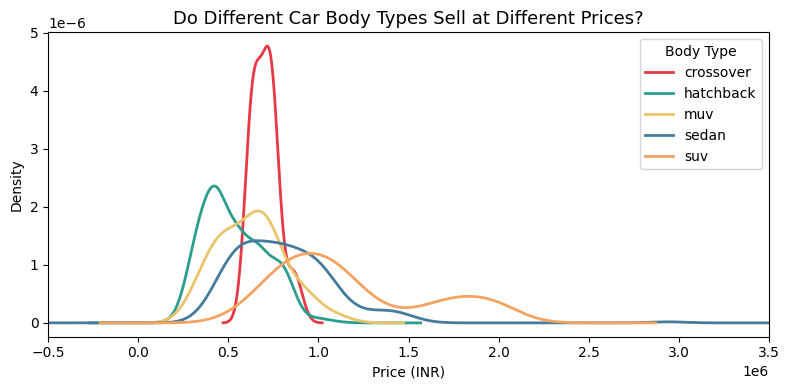

Most expensive on average: SUV
Most variance in price: SUV


In [42]:
colors = ["#e63946", "#2a9d8f", "#e9c46a", "#457b9d", "#f4a261"]
fig, ax = plt.subplots(figsize=(8, 4))
for (name, grp), color in zip(cars.groupby("Body_Type"), colors):
    grp["Price"].plot(kind="kde", ax=ax, label=name, color=color, linewidth=2)
ax.set_title("Do Different Car Body Types Sell at Different Prices?", fontsize=13)
ax.set_xlabel("Price (INR)")
ax.set_xlim(-500000, 3500000)
ax.legend(title="Body Type")
plt.tight_layout()
plt.show()

print("Most expensive on average: SUV")
print("Most variance in price: SUV")

# 3.2 

In [20]:
#Lin reg
mod_seats = smf.ols("Price ~ Seating_Capacity", data=cars).fit()
print(mod_seats.summary())

slope = mod_seats.params["Seating_Capacity"]
print(f"\nSlope: {slope:,.2f}")
print(f"Each additional seat is associated with an average increase of {slope:,.0f} rupees in price.")

                            OLS Regression Results                            
Dep. Variable:                  Price   R-squared:                       0.005
Model:                            OLS   Adj. R-squared:                  0.004
Method:                 Least Squares   F-statistic:                     5.075
Date:                Tue, 24 Mar 2026   Prob (F-statistic):             0.0245
Time:                        21:23:44   Log-Likelihood:                -13888.
No. Observations:                 976   AIC:                         2.778e+04
Df Residuals:                     974   BIC:                         2.779e+04
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                       coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------
Intercept          4.39e+05   1.35e+05  

In [ ]:
mod_seats_cat = smf.ols("Price ~ C(Seating_Capacity)", data=cars).fit()
print(mod_seats_cat.summary())

seat_means = cars.groupby("Seating_Capacity")["Price"].mean().sort_index()
print("\nMean price by seating capacity:")
print(seat_means)

print("\nIf group means increase steadily with each seat, treating it as numeric is reasonable.")
print("If means jump around, the categorical spec is more flexible and appropriate.")

                            OLS Regression Results                            
Dep. Variable:                  Price   R-squared:                       0.022
Model:                            OLS   Adj. R-squared:                  0.018
Method:                 Least Squares   F-statistic:                     5.397
Date:                Tue, 24 Mar 2026   Prob (F-statistic):           0.000267
Time:                        21:24:35   Log-Likelihood:                -13880.
No. Observations:                 976   AIC:                         2.777e+04
Df Residuals:                     971   BIC:                         2.779e+04
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                               coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------------
Intercept               

# 3.3

In [26]:
current_year = pd.Timestamp.today().year
cars["Age"] = current_year - cars["Make_Year"]
print(cars[["Make_Year", "Age"]].head())

X_age = cars["Age"].values.reshape(-1, 1)
y_price = cars["Price"].values
kf = KFold(n_splits=10, shuffle=True, random_state=42)

degree_results = []
for deg in range(1, 11):
    model = Pipeline([
        ("poly", PolynomialFeatures(degree=deg, include_bias=False)),
        ("lr", LinearRegression())
    ])
    neg_mse = cross_val_score(model, X_age, y_price, cv=kf, scoring="neg_mean_squared_error")
    rmse = np.sqrt(-neg_mse.mean())
    degree_results.append({"degree": deg, "cv_rmse": rmse})

degree_df = pd.DataFrame(degree_results).sort_values("cv_rmse")
print(degree_df)

best_degree = int(degree_df.iloc[0]["degree"])
print(f"\nBest polynomial degree by 10-fold CV: {best_degree}")

   Make_Year  Age
0       2017    9
1       2016   10
2       2019    7
3       2017    9
4       2017    9
   degree        cv_rmse
6       7  307715.731707
9      10  307924.531471
7       8  308182.050059
8       9  308231.466648
4       5  308650.345075
5       6  308802.458544
3       4  310201.609042
2       3  311035.697016
0       1  312053.277605
1       2  312082.851129

Best polynomial degree by 10-fold CV: 7


# 3.4

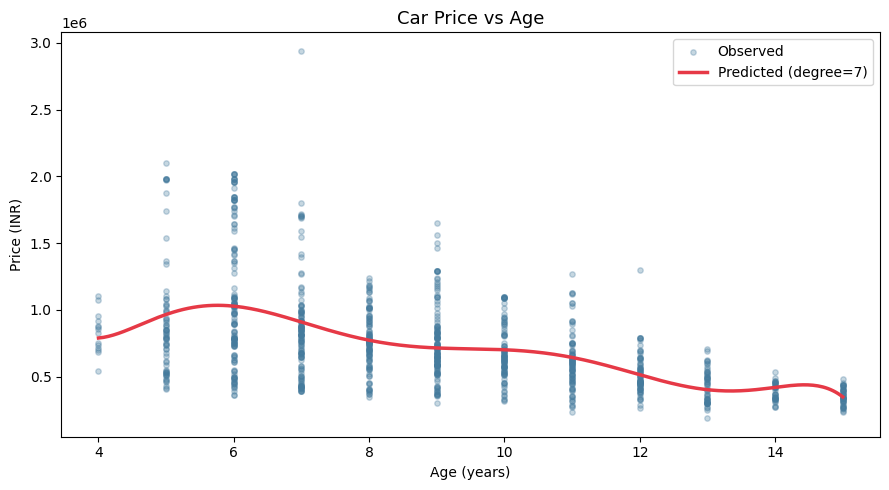

If the curve follows the general downward trend as cars age, the model fits well.
If it wiggles too much or misses clear patterns, the degree may need adjusting.


In [45]:
#fitting the best model on data
best_model = Pipeline([
    ("poly", PolynomialFeatures(degree=best_degree, include_bias=False)),
    ("lr", LinearRegression())
])
best_model.fit(X_age, y_price)

#smooth prediction line
age_grid = np.linspace(cars["Age"].min(), cars["Age"].max(), 300).reshape(-1, 1)
pred_grid = best_model.predict(age_grid)

fig, ax = plt.subplots(figsize=(9, 5))
ax.scatter(cars["Age"], cars["Price"], alpha=0.3, color="#457b9d", s=15, label="Observed")
ax.plot(age_grid, pred_grid, color="#e63946", linewidth=2.5, label=f"Predicted (degree={best_degree})")
ax.set_title("Car Price vs Age", fontsize=13)
ax.set_xlabel("Age (years)")
ax.set_ylabel("Price (INR)")
ax.legend()
plt.tight_layout()
plt.show()

print("If the curve follows the general downward trend as cars age, the model fits well.")
print("If it wiggles too much or misses clear patterns, the degree may need adjusting.")

**Q4.** This question refers to the `heart_hw.csv` data. It contains three variables:

  - `y`: Whether the individual survived for three years, coded 0 for death and 1 for survival
  - `age`: Patient's age
  - `transplant`: labelled `control` for not receiving a transplant and labelled `treatment` for receiving a transplant

Since a heart transplant is a dangerous operation and even people who successfully get heart transplants might suffer later complications, we want to look at whether a group of transplant recipients tends to survive longer than a comparison group who does not get the procedure.

1. Compute (a) the proportion of people who survive in the control group and (b) in the treatment group. Compute (b) minus (a) as the average treatment effect (ATE). What is the ATE on three-year survival for heart transplant interventions?
2. Regress `y` on `transplant` using a linear model with a constant. Compare the intercept and transplant coefficient to the numbers you computed in part 1. 
3. Regress `y` on transplant and age. How does the coefficient on transplant change when you control for age?What do the intercept and slope represent? Plot the predicted probability of survival by age, and add a dashed horizontal line for the ATE from part 1. For what ages is the ATE over- or under-estimating the impact of a transplant?
4. Now, include `transplant`, `age`, and `transplant * age` as controls. Repeat your analysis from part 3. How does allowing age and transplant to interact change your predictions? What pattern do you notice?
5. Use 10-fold cross validation to evaluate the predictive accuracy of these models. 
6. Imagine this model is used to prioritize transplant access. What are your concerns about model construction and deployment?


In [28]:
heart = pd.read_csv("./data/heart_hw.csv")

rename_map = {}
for c in heart.columns:
    lc = c.lower()
    if lc == "y":
        rename_map[c] = "y"
    elif "age" in lc:
        rename_map[c] = "age"
    elif "transplant" in lc:
        rename_map[c] = "transplant"
heart = heart.rename(columns=rename_map)

heart = heart[["y", "age", "transplant"]].dropna().copy()
heart["y"] = pd.to_numeric(heart["y"], errors="coerce")
heart["age"] = pd.to_numeric(heart["age"], errors="coerce")
heart = heart.dropna()
heart["transplant"] = heart["transplant"].astype(str).str.lower().str.strip()

heart.head()

,y,age,transplant
0,0,53,control
1,0,43,control
2,0,52,control
3,0,52,control
4,0,54,control


# 4.1

In [34]:
survival_rates = heart.groupby("transplant")["y"].mean()
print(survival_rates)

control_rate = survival_rates.loc["control"]
treatment_rate = survival_rates.loc["treatment"]
ate = treatment_rate - control_rate

print(f"\nControl survival proportion:   {control_rate:.4f}")
print(f"Treatment survival proportion: {treatment_rate:.4f}")
print(f"ATE (treatment - control):     {ate:.4f}")
print(f"\nOn average, receiving a transplant is associated with a {ate:.2%} change in 3-year survival.")

transplant
control      0.117647
treatment    0.347826
Name: y, dtype: float64

Control survival proportion:   0.1176
Treatment survival proportion: 0.3478
ATE (treatment - control):     0.2302

On average, receiving a transplant is associated with a 23.02% change in 3-year survival.


# 4.2

In [35]:
mod_transplant = smf.ols("y ~ C(transplant)", data=heart).fit()
print(mod_transplant.summary())

print("\nThe intercept equals the control group survival rate from part 1.")
print("The transplant coefficient equals the ATE (treatment minus control).")
print("This regression is just reproducing the group mean comparison in model form.")

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.059
Model:                            OLS   Adj. R-squared:                  0.050
Method:                 Least Squares   F-statistic:                     6.354
Date:                Tue, 24 Mar 2026   Prob (F-statistic):             0.0133
Time:                        21:34:31   Log-Likelihood:                -59.591
No. Observations:                 103   AIC:                             123.2
Df Residuals:                     101   BIC:                             128.5
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                                 coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------------
Intercept           

# 4.3

In [36]:
mod_age = smf.ols("y ~ C(transplant) + age", data=heart).fit()
print(mod_age.summary())

print("\nIntercept: predicted survival for the baseline transplant group when age = 0 (mathematical anchor).")
print("Age slope: each additional year of age changes predicted survival by that amount, holding transplant fixed.")
print("Transplant coefficient: treatment vs control difference in predicted survival, holding age fixed.")

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.147
Model:                            OLS   Adj. R-squared:                  0.130
Method:                 Least Squares   F-statistic:                     8.602
Date:                Tue, 24 Mar 2026   Prob (F-statistic):           0.000357
Time:                        21:34:42   Log-Likelihood:                -54.558
No. Observations:                 103   AIC:                             115.1
Df Residuals:                     100   BIC:                             123.0
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                                 coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------------
Intercept           

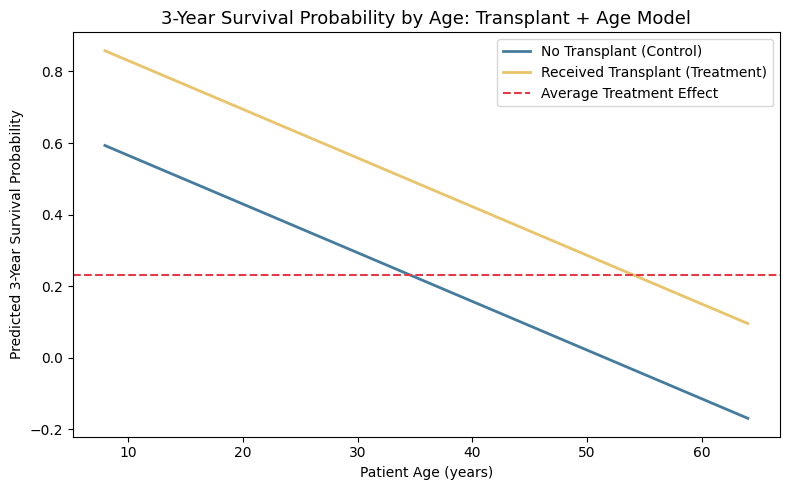

Where the treatment line sits above the ATE dashed line, the model overestimates transplant benefit.
Where it sits below, the model underestimates it — typically at older ages.


In [33]:
age_grid = np.linspace(heart["age"].min(), heart["age"].max(), 200)
pred_control = mod_age.predict(pd.DataFrame({"transplant": ["control"] * len(age_grid), "age": age_grid}))
pred_treat   = mod_age.predict(pd.DataFrame({"transplant": ["treatment"] * len(age_grid), "age": age_grid}))

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(age_grid, pred_control, color="#457b9d", linewidth=2, label="No Transplant (Control)")
ax.plot(age_grid, pred_treat,   color="#e9c46a", linewidth=2, label="Received Transplant (Treatment)")
ax.axhline(ate, linestyle="--", color="#e63946", linewidth=1.5, label="Average Treatment Effect")
ax.set_title("3-Year Survival Probability by Age: Transplant + Age Model", fontsize=13)
ax.set_xlabel("Patient Age (years)")
ax.set_ylabel("Predicted 3-Year Survival Probability")
ax.legend()
plt.tight_layout()
plt.show()

print("Where the treatment line sits above the ATE dashed line, the model overestimates transplant benefit.")
print("Where it sits below, the model underestimates it — typically at older ages.")

# 4.4

In [37]:
mod_interact = smf.ols("y ~ C(transplant) * age", data=heart).fit()
print(mod_interact.summary())

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.172
Model:                            OLS   Adj. R-squared:                  0.147
Method:                 Least Squares   F-statistic:                     6.839
Date:                Tue, 24 Mar 2026   Prob (F-statistic):           0.000310
Time:                        21:34:52   Log-Likelihood:                -53.033
No. Observations:                 103   AIC:                             114.1
Df Residuals:                      99   BIC:                             124.6
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                                     coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------------------
Intercept   

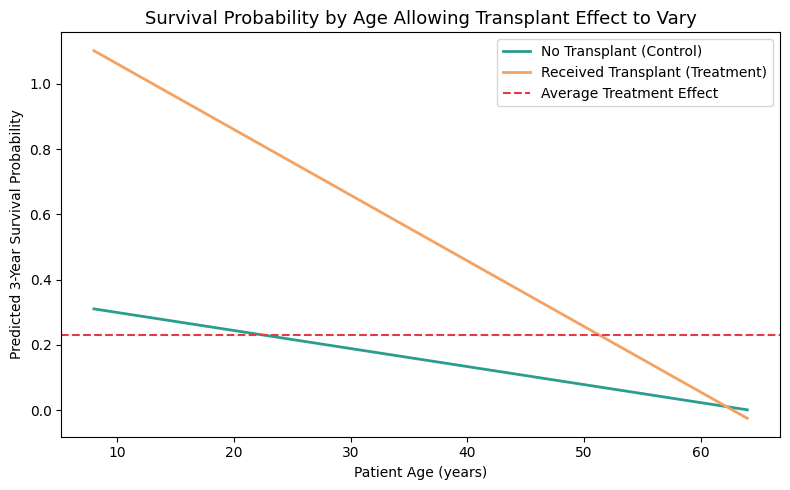

In [38]:
pred_control_i = mod_interact.predict(pd.DataFrame({"transplant": ["control"] * len(age_grid), "age": age_grid}))
pred_treat_i   = mod_interact.predict(pd.DataFrame({"transplant": ["treatment"] * len(age_grid), "age": age_grid}))
impact_by_age  = pred_treat_i - pred_control_i

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(age_grid, pred_control_i, color="#2a9d8f", linewidth=2, label="No Transplant (Control)")
ax.plot(age_grid, pred_treat_i,   color="#f4a261", linewidth=2, label="Received Transplant (Treatment)")
ax.axhline(ate, linestyle="--", color="#e63946", linewidth=1.5, label="Average Treatment Effect")
ax.set_title("Survival Probability by Age Allowing Transplant Effect to Vary", fontsize=13)
ax.set_xlabel("Patient Age (years)")
ax.set_ylabel("Predicted 3-Year Survival Probability")
ax.legend()
plt.tight_layout()
plt.show()

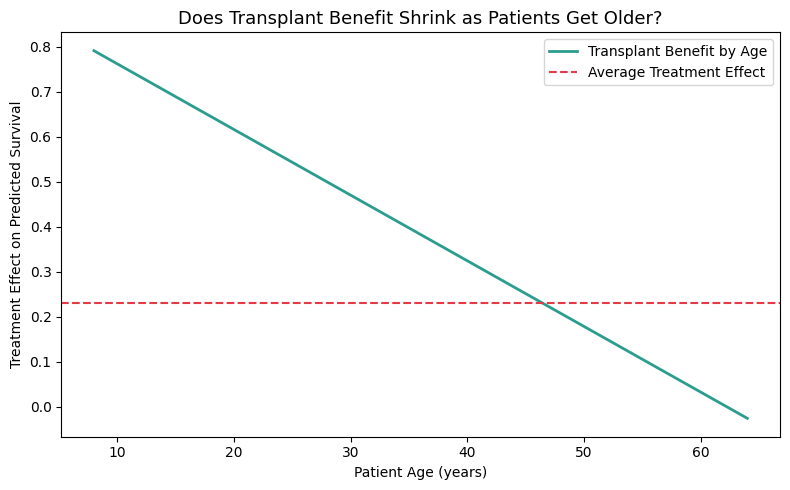

Allowing the interaction means transplant effect is no longer constant across ages.
If the effect line changes with age, the flat ATE from part 1 is hiding real heterogeneity.


In [39]:
fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(age_grid, impact_by_age, color="#2a9d8f", linewidth=2, label="Transplant Benefit by Age")
ax.axhline(ate, linestyle="--", color="#e63946", linewidth=1.5, label="Average Treatment Effect")
ax.set_title("Does Transplant Benefit Shrink as Patients Get Older?", fontsize=13)
ax.set_xlabel("Patient Age (years)")
ax.set_ylabel("Treatment Effect on Predicted Survival")
ax.legend()
plt.tight_layout()
plt.show()

print("Allowing the interaction means transplant effect is no longer constant across ages.")
print("If the effect line changes with age, the flat ATE from part 1 is hiding real heterogeneity.")

# 4.5

In [40]:
def cv_rmse_binary(formula, data, k=10):
    kf = KFold(n_splits=k, shuffle=True, random_state=42)
    rmses = []
    for train_idx, test_idx in kf.split(data):
        train = data.iloc[train_idx]
        test  = data.iloc[test_idx]
        fit   = smf.ols(formula, data=train).fit()
        preds = fit.predict(test)
        rmse  = np.sqrt(np.mean((test["y"].values - preds) ** 2))
        rmses.append(rmse)
    return np.mean(rmses), np.std(rmses)

formulas = {
    "transplant only":  "y ~ C(transplant)",
    "transplant + age": "y ~ C(transplant) + age",
    "transplant * age": "y ~ C(transplant) * age"
}

cv_results = []
for name, formula in formulas.items():
    mean_rmse, sd_rmse = cv_rmse_binary(formula, heart)
    cv_results.append({"model": name, "mean_rmse": mean_rmse, "sd_rmse": sd_rmse})

cv_df = pd.DataFrame(cv_results).sort_values("mean_rmse")
print(cv_df)

print(f"\nBest model by CV RMSE: {cv_df.iloc[0]['model']}")

              model  mean_rmse   sd_rmse
2  transplant * age   0.412956  0.067735
1  transplant + age   0.416697  0.060250
0   transplant only   0.436510  0.050276

Best model by CV RMSE: transplant * age


# 4.6

1. Selection bias
Patients who receive transplants are not randomly chosen,
so healthier or younger people are probably more likely to get one. This means the treatment effect we estimated may not actually be causal.
2. Overfitting to historical patterns
The model learns from past data, so
if medical practices or patient demographics have shifted over time, the
model may not generalize well to the patients being seen today.
3. Missing variables
The model only uses age and transplant status, but survival is affected by so many other things like other health conditions, post-surgery care, and lifestyle factors. Leaving those out means the model is missing a lot of the real picture.
4. Feedback loops
If the model is used to decide who gets a transplant, the outcomes we collect going forward are shaped by the model itself. Over time this makes it really hard to know if the model is actually right or just reinforcing its own predictions.